In [1]:
import uproot
import awkward as ak
import argparse
import logging
from tqdm import tqdm
from pathlib import Path
import os


os.chdir('/global/cfs/cdirs/m4474/aneek/particlemind')

from src.datasets.CLDHits import CLDHits

In [2]:

'''
An object representing calorimeter hits

'''

import numpy as np


class CaloEvent:
    """
    Represents a calorimeter event with hits:
    columns: [x, y, z, E]
    """

    def __init__(self, hits: np.ndarray):
        assert hits.ndim == 2 and hits.shape[1] == 4
        self.hits = hits.astype(np.float32)

    @property
    def xyz(self):
        return self.hits[:, :3]

    @property
    def energy(self):
        return self.hits[:, 3]

    def copy(self):
        return CaloEvent(self.hits.copy())

    def apply(self, transform):
        return transform(self)

    def __repr__(self):
        return f"CaloEvent(num_hits={len(self.hits)})"


class Transform:
    def __call__(self, event: CaloEvent) -> CaloEvent:
        raise NotImplementedError


class RandomRotateXY(Transform):
    def __init__(self, angle_range=(0, 2*np.pi)):
        self.angle_range = angle_range

    def __call__(self, event: CaloEvent):
        event_c = event.copy()
        
        theta = np.random.uniform(*self.angle_range)

        #theta = np.pi/2

        cos_t = np.cos(theta)
        sin_t = np.sin(theta)

        x = event.hits[:, 0]
        y = event.hits[:, 1]

        event_c.hits[:, 0] = cos_t * x - sin_t * y
        event_c.hits[:, 1] = sin_t * x + cos_t * y

        return event_c
        
class RandomShift(Transform):
    def __init__(self, shift_std=(1.0, 1.0, 0.0)):
        self.shift_std = shift_std

    def __call__(self, event: CaloEvent):
        event = event.copy()
        dx = np.random.normal(0, self.shift_std[0])
        dy = np.random.normal(0, self.shift_std[1])
        dz = np.random.normal(0, self.shift_std[2])

        event.hits[:, 0] += dx
        event.hits[:, 1] += dy
        event.hits[:, 2] += dz

        return event


class RandomSpatialCrop(Transform):
    """
    Masks hits inside a random spatial box by setting their energy to zero.
    Array length remains unchanged.
    """

    def __init__(self, crop_fraction=0.2):
        self.crop_fraction = crop_fraction

    def __call__(self, event: CaloEvent):
        event_c = event.copy()

        xyz = event.xyz
        N = len(xyz)

        if N == 0:
            return event

        # Choose random hit as center
        center = xyz[np.random.randint(N)]

        # Estimate scale of box from spread
        spread = np.std(xyz, axis=0)
        radius = self.crop_fraction * spread

        # Identify hits inside box
        inside_mask = np.all(
            np.abs(xyz - center) < radius,
            axis=1
        )

        # Zero out energies instead of deleting hits
        event_c.hits[inside_mask, 3] = 0.0

        return event_c


class EnergyWhiteNoise(Transform):
    """
    Adds Gaussian white noise to calorimeter hit energies.

    E -> E + N(0, sigma)

    Parameters
    ----------
    sigma : float
        Standard deviation of Gaussian noise.
    clip_min : float or None
        If set, energies are clipped below this value (e.g., 0.0).
    """

    def __init__(self, sigma=0.1, clip_min=0.0):
        self.sigma = sigma
        self.clip_min = clip_min

    def __call__(self, event: CaloEvent):
        event_c = event.copy()

        noise = np.abs(np.random.normal(
            loc=0.0,
            scale=self.sigma,
            size=len(event.hits)
        ))

        event_c.hits[:, 3] += noise

        if self.clip_min is not None:
            event_c.hits[:, 3] = np.clip(
                event_c.hits[:, 3],
                self.clip_min,
                None
            )

        return event_c

class Compose(Transform):
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, event):
        for t in self.transforms:
            event = t(event)
        return event





In [3]:
import torch
from torch_geometric.data import Data
from torch_geometric.nn import knn_graph

from torch_geometric.nn import radius_graph

'''
Creating graph for each event out of hits

'''


class EventGraphBuilder:
    def __init__(self, radius=1, max_neighbors=32):
        self.r = radius
        self.neighbors = max_neighbors

    def __call__(self, hits):
        """
        hits: numpy array or tensor [N, 4]
        """

        if not torch.is_tensor(hits):
            hits = torch.tensor(hits, dtype=torch.float)

        pos = hits[:, :3]      # spatial coordinates
        features = hits        # (x, y, z, E)

        #edge_index = knn_graph(pos, k=self.k, loop=False)

        pos = hits[:, :3]
        N = pos.shape[0]

        # Compute pairwise squared distances
        diff = pos.unsqueeze(1) - pos.unsqueeze(0)  # [N, N, 3]
        dist2 = (diff ** 2).sum(-1)

        # Select edges within radius (exclude self)
        row, col = torch.where((dist2 <= self.r ** 2) & (dist2 > 0))
        edge_index = torch.stack([row, col], dim=0)

        return Data(x=features, edge_index=edge_index)


import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import EdgeConv, global_mean_pool

'''
Designing a GNN type encoder

'''

class GNNEncoder(nn.Module):
    def __init__(self, hidden_dim=64, latent_dim=128, builder=EventGraphBuilder):
        super().__init__()

        def mlp(in_dim, out_dim):
            return nn.Sequential(
                nn.Linear(in_dim, out_dim),
                nn.ReLU(),
                nn.Linear(out_dim, out_dim)
            )

        self.conv1 = EdgeConv(mlp(2*4, hidden_dim))
        self.conv2 = EdgeConv(mlp(2*hidden_dim, 2*hidden_dim))
        self.conv3 = EdgeConv(mlp(4*hidden_dim, 4*hidden_dim))

        self.project = nn.Sequential(
            nn.Linear(4*hidden_dim, 2*hidden_dim),
            nn.ReLU(),
            nn.Linear(2*hidden_dim, latent_dim)
        )

    def forward(self, data):

        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = self.conv3(x, edge_index)

        # Global pooling → event-level vector
        x = global_mean_pool(x, batch)

        z = self.project(x)

        return z



/global/homes/a/aneekj02/.conda/envs/colliderml-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
import torch
from torch.utils.data import IterableDataset


class ContrastiveLearningDataset(IterableDataset):
    """
    Wraps an iterable dataset of calorimeter events.

    Yields:
        original, view1, view2
    """

    def __init__(self, base_dataset, transform=None):
        super().__init__()
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):

        return len(self.base_dataset)

    def __iter__(self):
        for event_dict in self.base_dataset:

            event = event_dict["calo_hit_features"]

            if not isinstance(event, CaloEvent):
                event = CaloEvent(event)

            if self.transform is None:
                view1 = event.copy()
                view2 = event.copy()
            else:
                view1 = self.transform(event)
                view2 = self.transform(event)

            
                
            event_dict["calo_hit_features_1"] = view1.hits
            event_dict["calo_hit_features_2"] = view2.hits
            event_dict["calo_hit_features"] = event.hits

            yield event_dict
            

'''

Create dataloader later based on this dataset


'''

class ContrastiveLearningGraphDataset(IterableDataset):
    """
    Wraps an iterable dataset of calorimeter events.

    Yields:
         view1_graph, view2_graph
    """

    def __init__(self, base_dataset, builder=EventGraphBuilder):
        super().__init__()
        self.base_dataset = base_dataset
        self.builder = builder

    def __len__(self):

        return len(self.base_dataset)

    def __iter__(self):
        for event_dict in self.base_dataset:

            view1 = event_dict["calo_hit_features_1"]
            view2 = event_dict["calo_hit_features_2"]

            view1_graph = self.builder()(view1)
            view2_graph = self.builder()(view2)

            yield view1_graph, view2_graph
            



In [5]:
augment = Compose([
    RandomRotateXY((0, 2*np.pi))
    ,
    RandomShift((20.0, 20.0, 0.0)),
    RandomSpatialCrop(0.7),
    EnergyWhiteNoise(0.2)
])


"""
parquet_dir = '/global/cfs/cdirs/m4474/aneek/particlemind/scripts/data/p8_ee_tt_ecm365_parquet'

dataset_train = CLDHits(parquet_dir, "train", nfiles=10, by_event=True)
dataset_val = CLDHits(parquet_dir, "val", nfiles=10, by_event=True)

dataset_train = ContrastiveIterableDataset2(ContrastiveIterableDataset(dataset_train, augment))
dataset_val = ContrastiveIterableDataset2(ContrastiveIterableDataset(dataset_val, augment))
"""




In [15]:
"""
The ColliderML dataset

"""



from colliderml.core import load_tables, collect_tables


## ttbar data
cfg1 = {
    "dataset_id": "CERN/ColliderML-Release-1",
    "channels": "ttbar",
    "pileup": "pu0",
    "objects": ["calo_hits"],
    "split": "train",
    "lazy": False,
    "max_events": 6400,
    "data_dir":"/pscratch/sd/a/aneekj02/colliderml-data"
}
tables1 = load_tables(cfg1)
frames1 = collect_tables(tables1)

calo_hits1 = frames1["calo_hits"]


## dihiggs data
cfg2 = {
    "dataset_id": "CERN/ColliderML-Release-1",
    "channels": "dihiggs",
    "pileup": "pu0",
    "objects": ["calo_hits"],
    "split": "train",
    "lazy": False,
    "max_events": 6400,
    "data_dir":"/pscratch/sd/a/aneekj02/colliderml-data"
}
tables2 = load_tables(cfg1)
frames2 = collect_tables(tables1)

calo_hits2 = frames2["calo_hits"]

import polars as pl

# Concatenate
combined = pl.concat([calo_hits1, calo_hits2])

# Shuffle rows
combined = combined.sample(fraction=1.0, with_replacement=False, seed=42)

#print(combined.shape)
#print(combined.head())

calo_hits = combined






"""
Data Preprocessor

"""

class ColliderMLHits(IterableDataset):
    def __init__(
        self, calo_hits, split, shuffle_files=False, train_fraction=0.8):
        """
        Initialize the dataset.

        Args:
            calo_hits : calo_hit data for events.
            shuffle_files (bool): Whether to shuffle the order of parquet files.
        """
        
        self.calo_hits = calo_hits
        self.shuffle_files = shuffle_files
        

        self.split = split
        if self.split is not None:
            split_index = int(len(self.calo_hits) * train_fraction)
            if self.split == "train":
                self.calo_hits = self.calo_hits[:split_index]
            elif self.split == "val":
                self.calo_hits = self.calo_hits[split_index:]

        if self.shuffle_files:
            self.shuffle_shards()

    def __len__(self):
        """
        Return the number of events in the dataset.
        """
        return len(self.calo_hits) 

    def shuffle_shards(self):
        """
        Shuffle the events in calo_hits
        """
        random.shuffle(self.calo_hits)

    def __iter__(self):
        logger = logging.getLogger(__name__)
        self.sample_counter = 0  # Reset sample counter for each iteration or each epoch
        #worker_info = torch.utils.data.get_worker_info()
        

        
        data = self.calo_hits
        
        for event_i in range(len(self.calo_hits)):

            data_i = data[event_i]

            calo_hit_features = np.column_stack(
                (
                    data_i['x'].to_numpy()[0],
                    data_i['y'].to_numpy()[0],
                    data_i['z'].to_numpy()[0],
                    data_i['total_energy'].to_numpy()[0]

                )
            )

            f_i = len(data_i['x'].to_numpy()[0]) if len(data_i['x'].to_numpy()[0])<8000 else 8000

            yield {

                "calo_hit_features": calo_hit_features[0:f_i]

            }
         


"""

Preparing dataset

"""

augment = Compose([
    RandomRotateXY((0, 2*np.pi))
    ,
    RandomShift((20.0, 20.0, 0.0)),
    RandomSpatialCrop(0.7),
    EnergyWhiteNoise(0.2)
])



dataset_train = ColliderMLHits(calo_hits, "train")
dataset_val = ColliderMLHits(calo_hits, "val")

dataset_train = ContrastiveLearningGraphDataset(ContrastiveLearningDataset(dataset_train, augment))
dataset_val = ContrastiveLearningGraphDataset(ContrastiveLearningDataset(dataset_val, augment))


In [16]:
#data = next(iter(dataset_train))
data_graph = next(iter(dataset_train))
print(data_graph)

(Data(x=[8000, 4], edge_index=[2, 0]), Data(x=[8000, 4], edge_index=[2, 0]))


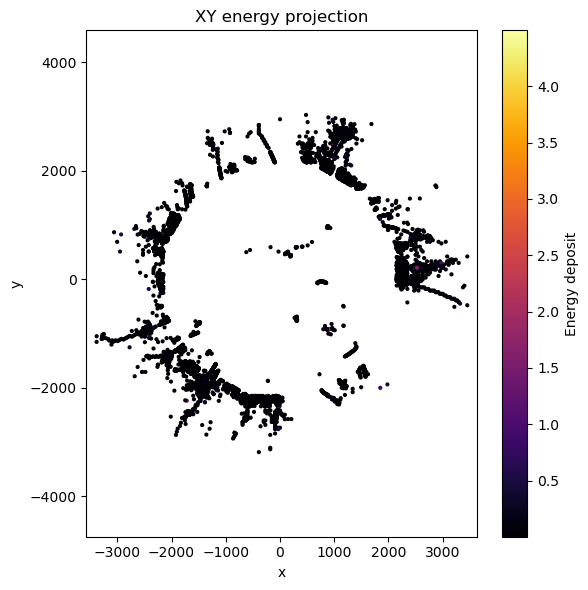

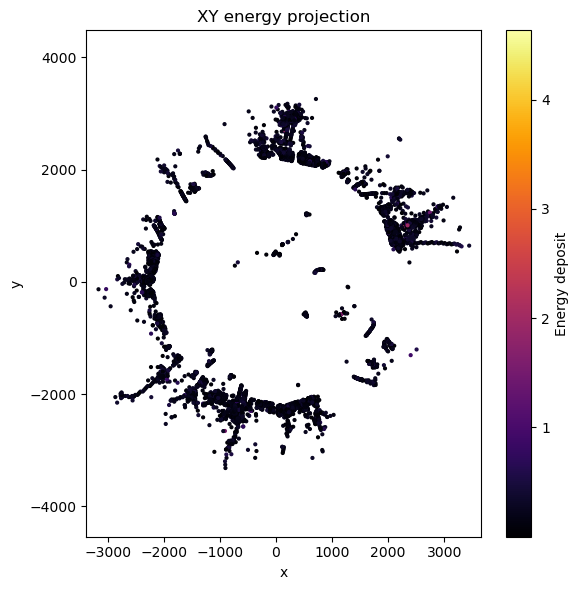

In [7]:
import matplotlib.pyplot as plt
import numpy as np


def plot_xy_energy(calo_hit_features):
    x = calo_hit_features[:, 0]
    y = calo_hit_features[:, 1]
    energy = calo_hit_features[:, 3]

    plt.figure(figsize=(6, 6))
    plt.scatter(x, y, c=energy, s=4, cmap="inferno")
    plt.colorbar(label="Energy deposit")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("XY energy projection")
    plt.axis("equal")
    plt.tight_layout()
    plt.show()



plot_xy_energy(data['calo_hit_features'])

plot_xy_energy(data['calo_hit_features_2'])

In [20]:
data_graph
GNNEncoder()(data_graph[0])[0]

tensor([-0.7996,  0.1053,  0.3316, -0.2893, -0.6128,  0.6696, -0.3650,  0.1929,
         1.3618,  0.6691,  0.3066, -0.7655,  0.1219,  0.3737,  0.3166, -0.6064,
        -0.8184, -1.4279,  1.2611,  0.4478,  0.7834,  0.3630, -0.4308,  0.1719,
         0.0847,  0.0244, -0.1079, -0.1649,  0.5100, -0.1973,  0.8022,  0.5856,
         0.9318, -0.5266, -0.2250, -1.0179,  0.3983, -0.4991, -0.7825,  0.1735,
         0.5084, -0.0845,  1.1664, -0.2425, -0.6402,  0.7402, -0.2877,  0.5745,
        -0.3910,  0.9335, -0.7113,  0.2747, -0.0904, -0.4959,  1.3506, -0.7540,
         0.2629,  0.3546,  0.0669, -0.7794,  0.1610, -0.2642,  0.1917, -0.1262,
        -0.4520,  0.4050,  1.0843,  0.6601,  0.1365,  1.1336, -0.1086, -0.2787,
        -0.6011, -0.8871, -0.1200, -0.2984,  0.5219, -0.8697, -0.9594, -0.5313,
         0.5191,  0.4953,  0.3307, -0.3783,  1.1702, -0.8161, -0.3786,  0.1564,
         0.0473,  0.2284,  0.0996,  0.0685, -0.0271,  0.4169,  0.1565,  0.8554,
         1.0886, -0.3343, -0.5177,  0.33

In [18]:

import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.cuda.amp import GradScaler, autocast
import logging
import os
import sys
from livelossplot import PlotLosses
from tqdm import tqdm
# The SimCLR training protocol


class Contrastive_Learning(object):

    def __init__(self, latent_dim=128, projector_hidden=256, *args, **kwargs):
        self.args = kwargs['args']
        self.model = kwargs['model'].to(self.args.device)
        self.optimizer = kwargs['optimizer']
        self.scheduler = kwargs['scheduler']
        self.criterion = torch.nn.CrossEntropyLoss().to(self.args.device)
        self.latent_dim = latent_dim
        self.projector_hidden = projector_hidden

        self.projector = nn.Sequential(
                nn.Linear(self.latent_dim, self.projector_hidden),
                nn.ReLU(),
                nn.Linear(self.projector_hidden, 64)
            ).to(self.args.device)

        

    def info_nce_loss(self, features):

        labels = torch.cat([torch.arange(self.args.batch_size) for i in range(self.args.n_views)], dim=0)
        labels = (labels.unsqueeze(0) == labels.unsqueeze(1)).float()
        labels = labels.to(self.args.device)

        features = F.normalize(features, dim=1)

        similarity_matrix = torch.matmul(features, features.T)
        # assert similarity_matrix.shape == (
        #     self.args.n_views * self.args.batch_size, self.args.n_views * self.args.batch_size)
        # assert similarity_matrix.shape == labels.shape

        # discard the main diagonal from both: labels and similarities matrix
        mask = torch.eye(labels.shape[0], dtype=torch.bool).to(self.args.device)
        labels = labels[~mask].view(labels.shape[0], -1)
        similarity_matrix = similarity_matrix[~mask].view(similarity_matrix.shape[0], -1)
        # assert similarity_matrix.shape == labels.shape

        # select and combine multiple positives
        positives = similarity_matrix[labels.bool()].view(labels.shape[0], -1)

        # select only the negatives the negatives
        negatives = similarity_matrix[~labels.bool()].view(similarity_matrix.shape[0], -1)

        logits = torch.cat([positives, negatives], dim=1)
        labels = torch.zeros(logits.shape[0], dtype=torch.long).to(self.args.device)

        logits = logits / self.args.temperature
        return logits, labels

    def forward(self, view):

        latent_vec = self.model(view)

        feat = self.projector(latent_vec)

        return feat
        
    def test(self, loader,desc=''):
        
        modelh = self.model
        
        modelh.eval()
        
        loss_ = 0
        
        with torch.no_grad():
        
            for view1, view2 in loader:
                
                view1 = view1.to(self.args.device)
                view2 = view2.to(self.args.device)

                feat1 = self.forward(view1)
                feat2 = self.forward(view2)

                features = torch.cat((feat1, feat2), dim=0)

                logits, labels = self.info_nce_loss(features)
                loss = self.criterion(logits, labels)
                loss_ += loss.item()

                
    
        
        return loss_/len(loader)
    
    
    

    def train(self, train_loader, val_loader, save_model = False, folder = '', wandb_ = False, **key_name):

        Scaler = GradScaler(enabled=self.args.fp16_precision)

        liveloss = PlotLosses()

        if wandb_ == True:

            import wandb

            wandb_key = key_name.get("key")
            
            if wandb_key is None:
               raise ValueError("wandb_=True but no wandb_key provided")
        
            wandb.login(key=wandb_key)
        
            wandb.init(project=key_name("name"), config=vars(self.args))

        
        n_iter = 0
    

        for epoch_counter in tqdm(range(self.args.epochs),desc='epoch'):
            loss_train = 0
            
            for view1, view2 in train_loader:
                
                view1 = view1.to(self.args.device)
                view2 = view2.to(self.args.device)

                feat1 = self.forward(view1)
                feat2 = self.forward(view2)

                features = torch.cat((feat1, feat2), dim=0)

                logits, labels = self.info_nce_loss(features)
                loss = self.criterion(logits, labels)
                loss_train += loss.item()

                self.optimizer.zero_grad()

                Scaler.scale(loss).backward()

                Scaler.step(self.optimizer)
                Scaler.update()
                
                n_iter += 1
            
            #loss_train = self.test(train_loader).item()
            loss_train = loss_train/len(train_loader)
            loss_val = self.test(val_loader,desc='validation')
            
            # LiveLossPlot logging
            liveloss.update({
                'loss_train': loss_train,
                'loss_val': loss_val
             })
            liveloss.send()

            if wandb_ == True:
                wandb.log({"loss_train": loss_train, "loss_val": loss_val})
            

            if save_model ==True:
                
                if epoch_counter%10==0:
                    save_path = folder + f"simclr_model_epoch_{epoch_counter+1}.pth"
                    torch.save(self.model.state_dict(), save_path)
                    print(f"Model saved to {save_path}")
                    #wandb.save(save_path)

                    
        if save_model ==True:
            save_path = folder+f"simclr_model_final.pth"
            torch.save(self.model.state_dict(), save_path)
            print(f"Model saved to {save_path}")
               

        

        if wandb_ == True:
            wandb.save(save_path)
            wandb.finish()


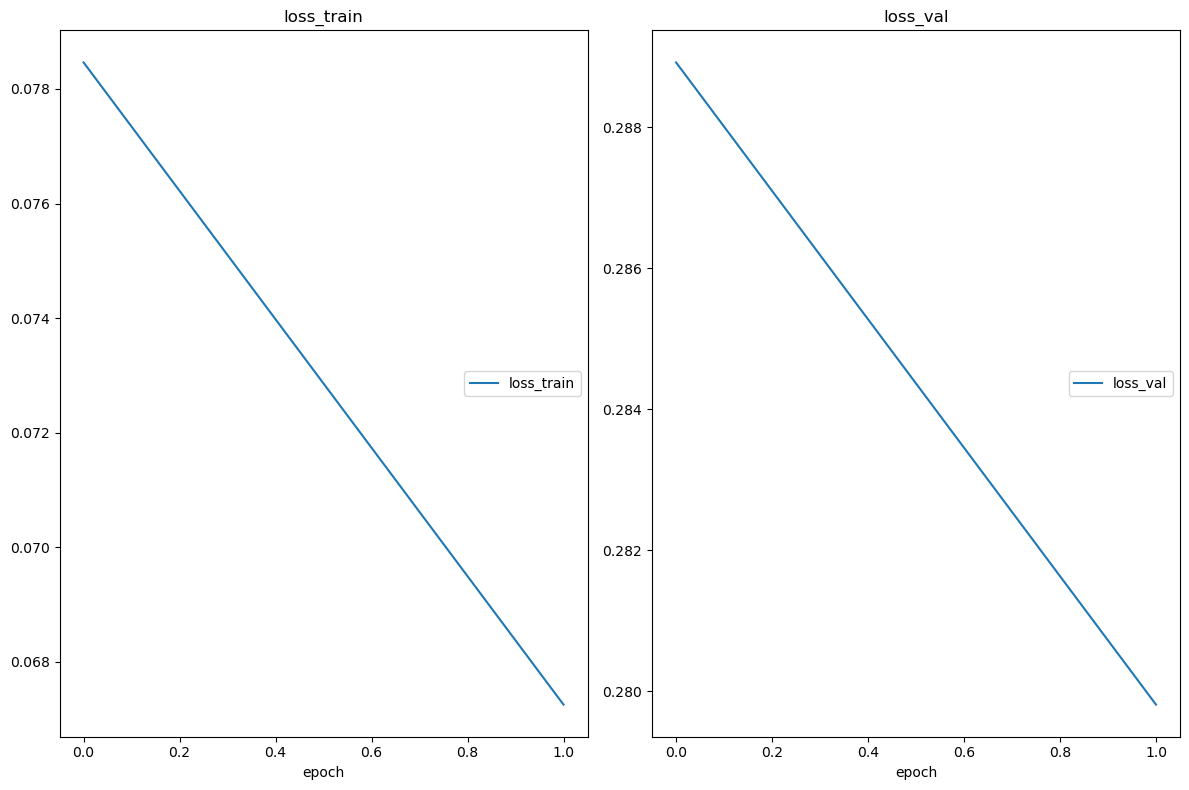

epoch:  40%|████      | 2/5 [10:43<16:05, 321.98s/it]

loss_train
	loss_train       	 (min:    0.067, max:    0.078, cur:    0.067)
loss_val
	loss_val         	 (min:    0.280, max:    0.289, cur:    0.280)


In [ ]:
from torch.utils.data import Dataset, DataLoader, random_split

from torch_geometric.loader import DataLoader

train_loader = DataLoader(dataset_train, batch_size=16, drop_last=True)
val_loader   = DataLoader(dataset_val,   batch_size=16, drop_last=True)

model = GNNEncoder()

for x1, x2 in train_loader:

    f1 = model(x1)
    f2 = model(x2)

    #print(f1.shape)

    #print(x1)

    
    break



## Train the SimCLR model!!


from torch.utils.tensorboard import SummaryWriter
import argparse
import torch
import torch.backends.cudnn as cudnn
from torchvision import models

model_names = sorted(name for name in models.__dict__
                     if name.islower() and not name.startswith("__")
                     and callable(models.__dict__[name]))

parser = argparse.ArgumentParser(description='PyTorch SimCLR')

#parser.add_argument('-data', metavar='DIR', default='./datasets',help='path to dataset')
'''
parser.add_argument('-dataset-name', default='stl10',
                    help='dataset name', choices=['stl10', 'cifar10'])

parser.add_argument('-a', '--arch', metavar='ARCH', default='resnet18',
                    choices=model_names,
                    help='model architecture: ' +
                         ' | '.join(model_names) +
                         ' (default: resnet50)')'''

parser.add_argument('-j', '--workers', default=12, type=int, metavar='N',
                    help='number of data loading workers (default: 32)')

parser.add_argument('--epochs', default=5, type=int, metavar='N',
                    help='number of total epochs to run')


parser.add_argument('-b', '--batch-size', default=16, type=int,
                    metavar='N',
                    help='mini-batch size, this is the total '
                         'batch size of all GPUs on the current node when '
                         'using Data Parallel or Distributed Data Parallel')


parser.add_argument('--lr', '--learning-rate', default=0.0003, type=float,
                    metavar='LR', help='initial learning rate', dest='lr')

parser.add_argument('--wd', '--weight-decay', default=1e-4, type=float,
                    metavar='W', help='weight decay (default: 1e-4)',
                    dest='weight_decay')

parser.add_argument('--seed', default=None, type=int,
                    help='seed for initializing training. ')

parser.add_argument('--disable-cuda', action='store_true',
                    help='Disable CUDA')

parser.add_argument('--fp16-precision', action='store_true',
                    help='Whether or not to use 16-bit precision GPU training.')

parser.add_argument('--out_dim', default=16, type=int,
                    help='latent space dimension where constrastive loss is applied')

parser.add_argument('--feat_dim', default=32, type=int,
                    help='feature dimension')

parser.add_argument('--log-every-n-steps', default=100, type=int,
                    help='Log every n steps')

parser.add_argument('--temperature', default=0.07, type=float,
                    help='softmax temperature (default: 0.07)')

parser.add_argument('--n-views', default=2, type=int, metavar='N',
                    help='Number of views for contrastive learning training.')

parser.add_argument('--gpu-index', default=0, type=int, help='Gpu index.')


args, unknown = parser.parse_known_args()

assert args.n_views == 2, "Only two view training is supported. Please use --n-views 2."
    # check if gpu training is available
if not args.disable_cuda and torch.cuda.is_available():
    args.device = torch.device('cuda')
    torch.backends.cudnn.deterministic = True
    cudnn.benchmark = True    
else:
    args.device = torch.device('cpu')
    args.gpu_index = -1


model = GNNEncoder()
# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), args.lr, weight_decay=args.weight_decay)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=len(train_loader), eta_min=0, last_epoch=-1)

#  It’s a no-op if the 'gpu_index' argument is a negative integer or None.


with torch.cuda.device(args.gpu_index):
    
    simclr = Contrastive_Learning(model=model, optimizer=optimizer, scheduler=scheduler, args=args)
    
    simclr.train(train_loader, val_loader, save_model=False, folder = '', wandb_=False)
    









In [ ]:
import torch
import torch.nn as nn
import lightning as L


class EventGNNModule(L.LightningModule):

    def __init__(
        self,
        encoder: nn.Module,
        latent_dim: int = 128,
        lr: float = 1e-3,
        weight_decay: float = 1e-4,
        use_projector: bool = True,
        projector_hidden: int = 256,
    ):
        super().__init__()
        self.save_hyperparameters(ignore=["encoder"])

        self.encoder = encoder

        if use_projector:
            self.projector = nn.Sequential(
                nn.Linear(latent_dim, projector_hidden),
                nn.ReLU(),
                nn.Linear(projector_hidden, 64)
            )
        else:
            self.projector = nn.Identity()

        self.lr = lr
        self.weight_decay = weight_decay

    # --------------------------------------------------
    # Forward Pass
    # --------------------------------------------------

    def forward(self, data):
        """
        batch: PyG Batch object
        returns: latent embedding [batch_size, latent_dim]
        """
        z = self.encoder(data)
        z = self.projector(z)
        return z

    def model_step(self, batch):

        view1, view2 = batch

        z1, z2 = self.forward(view1), self.forward(view2)

        features = torch.cat((z1, z2), dim=0)

        loss = self.loss_function(features)

        return loss

        

    # --------------------------------------------------
    # Training Step
    # --------------------------------------------------

    def training_step(self, batch, batch_idx):
        """
        batch expected format:
            view1_graph_batch, view2_graph_batch
        """

        loss = model_step(batch)

        self.log(
            "train_loss",
            loss.item(),
            prog_bar=True,
            on_step=True,
            on_epoch=True
        )

        return loss

    # --------------------------------------------------
    # Validation Step
    # --------------------------------------------------

    def validation_step(self, batch, batch_idx):
        """
        batch expected format:
            view1_graph_batch, view2_graph_batch
        """

        loss = model_step(batch)

        self.log(
            "val_loss",
            loss.item(),
            prog_bar=True,
            on_step=True,
            on_epoch=True
        )

        return loss

    # --------------------------------------------------
    # Loss Placeholder
    # --------------------------------------------------

    def compute_loss(self, z1, z2):
        """
        Implement your loss here.
        Example:
            - NT-Xent
            - VICReg
            - Barlow Twins
            - Supervised contrastive
        """
        raise NotImplementedError("Define your contrastive loss.")

    # --------------------------------------------------
    # Optimizer
    # --------------------------------------------------

    def configure_optimizers(self):

        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.lr,
            weight_decay=self.weight_decay
        )

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=self.trainer.max_epochs,
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": scheduler,
        }
